In [19]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import math
import seaborn as sns


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e3/train.csv
/kaggle/input/competitions/playground-series-s6e3/test.csv


In [2]:
training_data = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv', index_col=0)
test_data = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv', index_col=0)

In [3]:
training_data.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
id,,,,,,,,,,,,,,,,,,,,
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [4]:
print("Training data shape,", training_data.shape)
print("Test data shape", test_data.shape)

Training data shape, (594194, 20)
Test data shape (254655, 19)


In [5]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     594194 

In [6]:
training_data.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,594194.0,0.114102,0.317936,0.00,0.00,0.00,0.0,1.00
tenure,594194.0,36.577258,25.061922,1.00,12.00,35.00,62.0,72.00
MonthlyCharges,594194.0,65.866223,31.067444,18.25,29.90,74.10,90.8,118.75
TotalCharges,594194.0,2494.377057,2353.916710,18.80,639.65,1433.65,4263.8,8684.80


In [7]:
training_data.describe(include=['object']).T

,count,unique,top,freq
gender,594194,2,Female,298738
Partner,594194,2,Yes,309554
Dependents,594194,2,No,414362
PhoneService,594194,2,Yes,557893
MultipleLines,594194,3,No,283384
InternetService,594194,3,Fiber optic,272386
OnlineSecurity,594194,3,No,289474
OnlineBackup,594194,3,No,250083
DeviceProtection,594194,3,No,247377
TechSupport,594194,3,No,288571


In [8]:
categorical_features = (training_data.select_dtypes('object').columns.drop('Churn').tolist()) + ['SeniorCitizen']

numerical_features = training_data.select_dtypes(include=['int','float']).columns.drop('SeniorCitizen').tolist()

In [9]:
print("Missing Value count in training data", training_data.isna().sum().sum(),"\n")
print("Duplicate count in training data", training_data.duplicated().sum(), "\n")

print("Missing Value count in test data", test_data.isna().sum().sum(),"\n")
print("Duplicate count in test data", test_data.duplicated().sum(), "\n")

Missing Value count in training data 0 

Duplicate count in training data 0 

Missing Value count in test data 0 

Duplicate count in test data 0 



In [10]:
print("Unique Numeric Data\n", training_data[numerical_features].nunique(), "\n")
print("Unique Categorical Data\n", training_data[categorical_features].nunique(), "\n")

Unique Numeric Data
 tenure               72
MonthlyCharges     1921
TotalCharges      31910
dtype: int64 

Unique Categorical Data
 gender              2
Partner             2
Dependents          2
PhoneService        2
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
Contract            3
PaperlessBilling    2
PaymentMethod       4
SeniorCitizen       2
dtype: int64 



### Univariate EDA

##### Target Variable Distribution

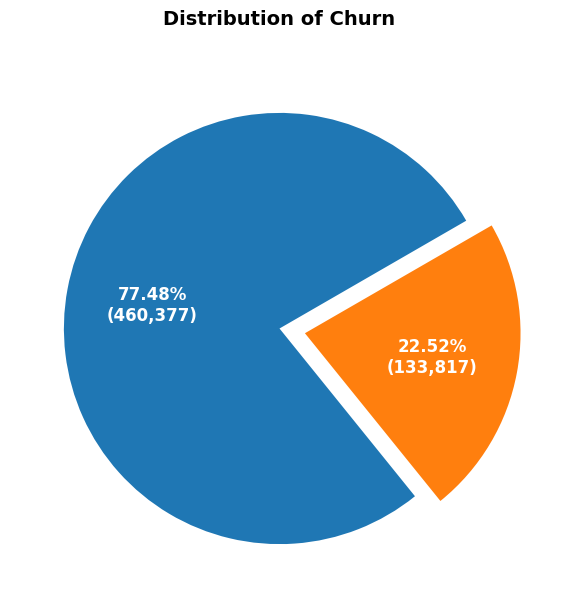

In [15]:
counts = training_data['Churn'].value_counts().sort_index()
labels = ['Yes', 'No']

plt.figure(figsize=(7,7))
plt.pie(counts, labels=labels, autopct=lambda pct: f'{pct:.2f}%\n({int(pct/100*len(training_data)):,})', startangle=30, textprops={'fontsize': 12, 'fontweight': 'bold', 'color': 'white'}, explode=(0, 0.12))

plt.title("Distribution of Churn", fontsize=14, fontweight='bold', pad=25)
plt.show()

#### Train-Test Distribution Drift

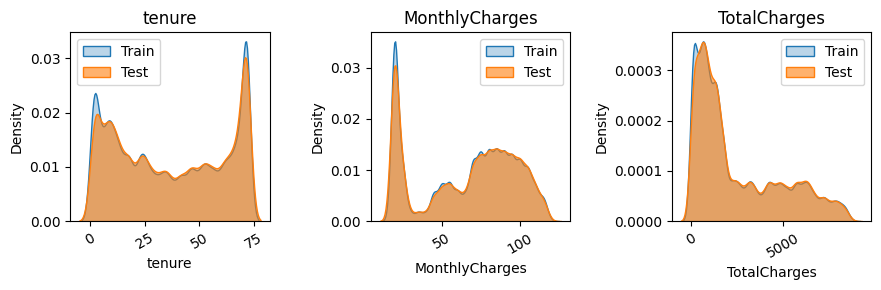

In [24]:
num_cols = 3
num_features = len(numerical_features)
num_rows = math.ceil(num_features / num_cols)

fig, axes = plt.subplots(
    num_rows,
    num_cols,
    figsize=(3 * num_cols, 3 * num_rows)
)
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.kdeplot(training_data[col], ax=axes[i], label='Train', fill=True, alpha=0.3)
    sns.kdeplot(test_data[col], ax=axes[i], label='Test', fill=True, alpha=0.6)
    axes[i].set_title(f'{col}')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Distribution of Numerical Features 

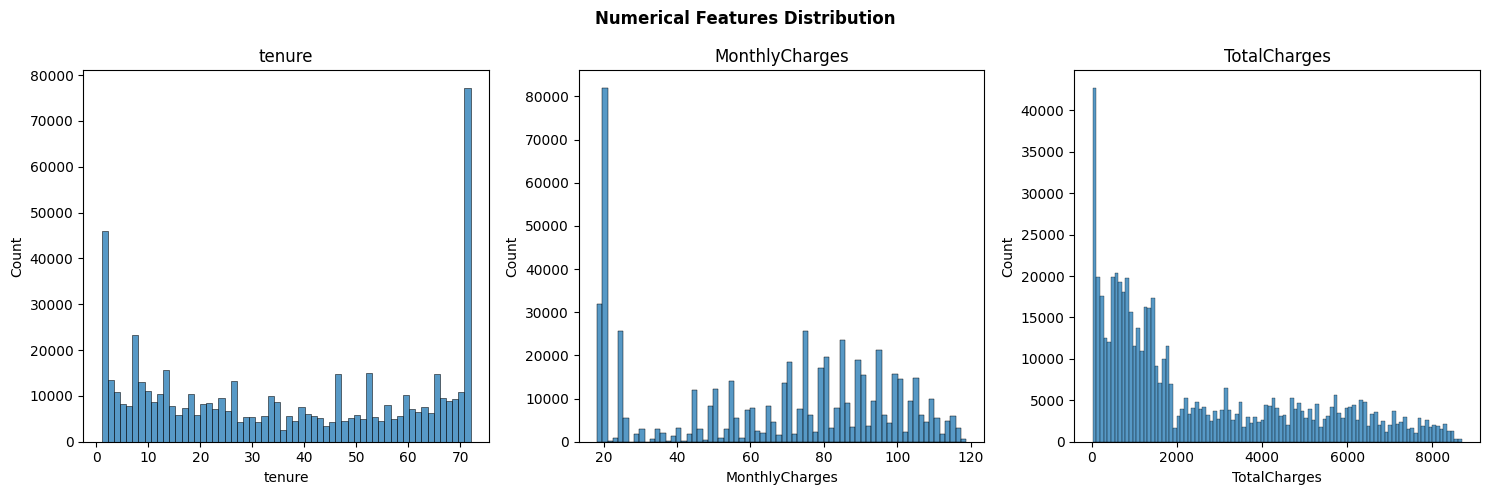

In [33]:
num_cols = 3
num_features = len(numerical_features)
num_rows = math.ceil(num_features / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))

axes = axes.flatten()
for i, col in enumerate(numerical_features):
    sns.histplot(training_data[col], ax=axes[i])
    axes[i].set_title(f'{col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Numerical Features Distribution", fontweight='bold')
plt.tight_layout()
plt.show()

#### Distribution of Categorical Features

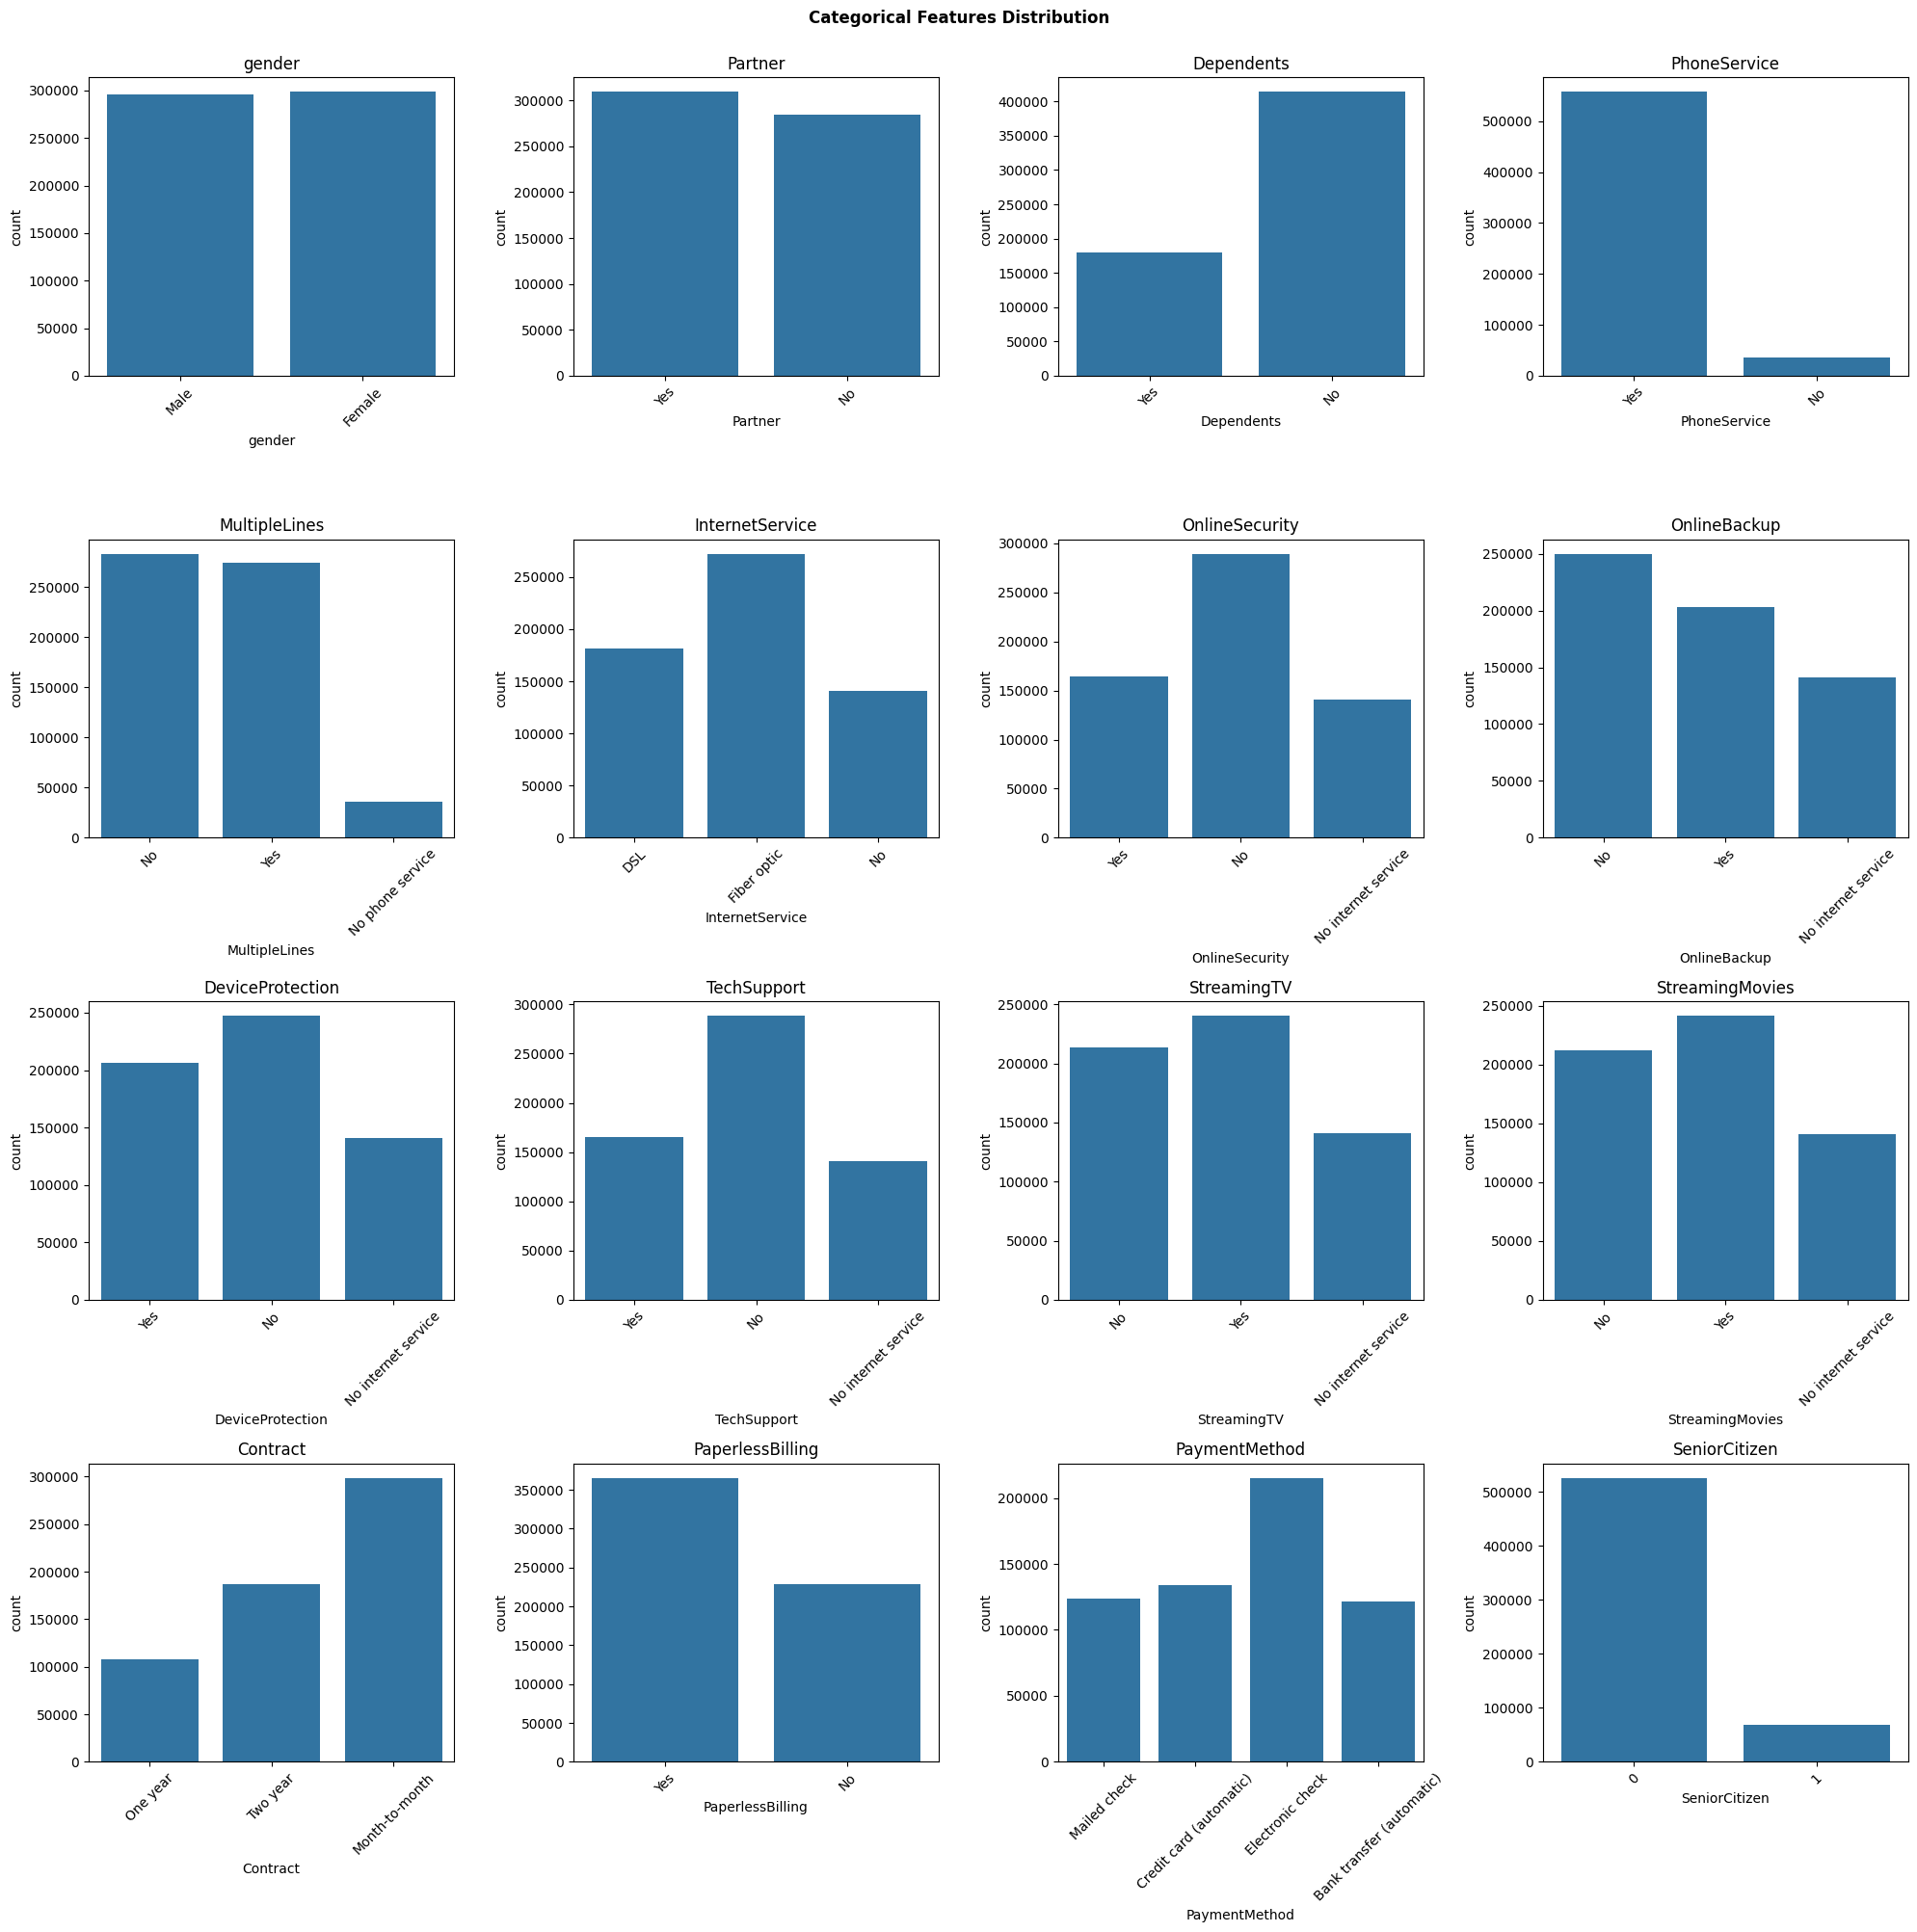

In [35]:
num_cols = 4
num_features = len(categorical_features)
num_rows = math.ceil(num_features / num_cols)

fig, axes = plt.subplots(num_rows, num_cols,figsize=(5 * num_cols, 5 * num_rows))

axes = axes.flatten()
for i, col in enumerate(categorical_features):
    sns.countplot(data=training_data, x=col, ax=axes[i])
    axes[i].set_title(f'{col}')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Categorical Features Distribution", y=1, fontweight='bold')
plt.tight_layout()
plt.show()

#### Outlier Analysis

In [37]:
for col in numerical_features:
    Q1 = training_data[col].quantile(0.25)
    Q3 = training_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"{col}: Lower bound = {lower_bound:.2f}, Upper bound = {upper_bound:.2f}")

    outliers = training_data[(training_data[col] < lower_bound) | (training_data[col] > upper_bound)]
    print(f"Number of outliers in {col}: {outliers.shape[0]}\n")

tenure: Lower bound = -63.00, Upper bound = 137.00
Number of outliers in tenure: 0

MonthlyCharges: Lower bound = -61.45, Upper bound = 182.15
Number of outliers in MonthlyCharges: 0

TotalCharges: Lower bound = -4796.58, Upper bound = 9700.03
Number of outliers in TotalCharges: 0

